In [1]:
!pip install transformers nltk pycocoevalcap rouge-score scikit-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 8.8 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=5bc237e77259098f75159da53005d696ce9352340c99fa14886ad7ff7f18c5a9
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [19]:
import os, re, torch, nltk, pandas as pd, numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split

from transformers import ViTModel, ViTImageProcessor

nltk.download('punkt')
nltk.download('punkt_tab') # Added to download the missing resource

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [39]:
data_dir = "/content/drive/MyDrive/archive/images/images_normalized"

reports = pd.read_csv("/content/drive/MyDrive/archive/indiana_reports.csv")
proj = pd.read_csv("/content/drive/MyDrive/archive/indiana_projections.csv")

df = reports.merge(proj, on="uid")
df = df[['filename','findings']].dropna()

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(len(train_df), len(val_df), len(test_df))

5175 647 647


In [40]:
def extract_cot_and_report(text):
    text = text.lower()
    sentences = nltk.sent_tokenize(text)

    cot, report = [], []

    for s in sentences:
        s_clean = re.sub(r'[^a-z0-9 ]', '', s)

        # Observation patterns (reasoning)
        if re.search(r"(lungs|heart|pleural|size|opacity|effusion|clear|normal)", s_clean):
            cot.append(s_clean)

        # Diagnostic conclusion
        if re.search(r"(no acute|disease|abnormality|impression)", s_clean):
            report.append(s_clean)

    if len(report) == 0:
        report = [sentences[-1]]

    return " ".join(cot), " ".join(report)

In [41]:
for d in [train_df, val_df, test_df]:
    d[['cot_text','report_text']] = d['findings'].apply(
        lambda x: pd.Series(extract_cot_and_report(x))
    )

In [42]:
all_text = list(train_df['cot_text']) + list(train_df['report_text'])

words = " ".join(all_text).split()
vocab = Counter(words)
vocab = [w for w,c in vocab.items() if c > 5][:1000]

word2idx = {w:i+1 for i,w in enumerate(vocab)}
word2idx['<pad>'] = 0
word2idx['<start>'] = len(word2idx)
word2idx['<end>'] = len(word2idx)

idx2word = {i:w for w,i in word2idx.items()}

In [43]:
class IU_Dataset(Dataset):
    def __init__(self, df, img_dir):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.extractor = ViTImageProcessor.from_pretrained(
            "google/vit-base-patch16-224"
        )

    def encode(self, text):
        seq = [word2idx.get(w,0) for w in text.split()]
        return [word2idx['<start>']] + seq + [word2idx['<end>']]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(os.path.join(self.img_dir,row['filename'])).convert("RGB")
        img = self.extractor(images=img, return_tensors="pt").pixel_values.squeeze()

        report = torch.tensor(self.encode(row['report_text']))
        cot = torch.tensor(self.encode(row['cot_text']))

        return img, report, cot

    def __len__(self):
        return len(self.df)

In [44]:
def pad(seq):
    max_len = max(len(s) for s in seq)
    out = torch.zeros(len(seq), max_len).long()
    for i,s in enumerate(seq):
        out[i,:len(s)] = s
    return out

def collate_fn(batch):
    imgs, reports, cots = zip(*batch)
    return torch.stack(imgs), pad(reports), pad(cots)

train_loader = DataLoader(IU_Dataset(train_df,data_dir),
                          batch_size=16, shuffle=True, collate_fn=collate_fn)

val_loader = DataLoader(IU_Dataset(val_df,data_dir),
                        batch_size=16, collate_fn=collate_fn)

test_loader = DataLoader(IU_Dataset(test_df,data_dir),
                         batch_size=16, collate_fn=collate_fn)

In [45]:
class CoAttention(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.Wv = nn.Linear(d,d)
        self.Wh = nn.Linear(d,d)
        self.Wa = nn.Linear(d,1)

    def forward(self,V,h):
        h = h.unsqueeze(1)
        e = self.Wa(torch.tanh(self.Wv(V)+self.Wh(h)))
        a = torch.softmax(e,1)
        return (a*V).sum(1)

In [46]:
class SentenceLSTM(nn.Module):
    def __init__(self,d):
        super().__init__()
        self.lstm = nn.LSTMCell(d,d)

    def forward(self,x,state):
        return self.lstm(x,state)

class WordLSTM(nn.Module):
    def __init__(self,vocab,d):
        super().__init__()
        self.emb = nn.Embedding(vocab,d)
        self.lstm = nn.LSTM(d+d,d,batch_first=True)
        self.fc = nn.Linear(d,vocab)

    def forward(self,topic,seq):
        emb = self.emb(seq[:,:-1])
        topic = topic.unsqueeze(1).repeat(1,emb.size(1),1)
        out,_ = self.lstm(torch.cat([emb,topic],-1))
        return self.fc(out)

In [47]:
class CoTDecoder(nn.Module):
    def __init__(self,vocab,d):
        super().__init__()
        self.emb = nn.Embedding(vocab,d)
        self.lstm = nn.LSTM(d+d,d,batch_first=True)
        self.fc = nn.Linear(d,vocab)

    def forward(self,context,seq):
        emb = self.emb(seq[:,:-1])
        context = context.unsqueeze(1).repeat(1,emb.size(1),1)
        out,_ = self.lstm(torch.cat([emb,context],-1))
        return self.fc(out)

In [48]:
class FullModel(nn.Module):
    def __init__(self,vocab,d=512):
        super().__init__()

        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224")
        self.proj = nn.Linear(768,d)

        self.attn = CoAttention(d)
        self.sent_lstm = SentenceLSTM(d)
        self.word_lstm = WordLSTM(vocab,d)
        self.cot = CoTDecoder(vocab,d)

    def forward(self,img,report,cot):

        V = self.proj(self.vit(img).last_hidden_state)

        B = img.size(0)
        h = torch.zeros(B,V.size(-1)).to(img.device)
        c = torch.zeros_like(h)

        context = self.attn(V,h)
        h,c = self.sent_lstm(context,(h,c))

        report_out = self.word_lstm(h,report)
        cot_out = self.cot(context,cot)

        return report_out, cot_out

In [49]:
crit = nn.CrossEntropyLoss(ignore_index=0)
lambda_cot = 0.4

def loss_fn(r_out,c_out,r,c):
    l1 = crit(r_out.reshape(-1,r_out.size(-1)), r[:,1:].reshape(-1))
    l2 = crit(c_out.reshape(-1,c_out.size(-1)), c[:,1:].reshape(-1))
    return l1 + lambda_cot*l2

In [51]:
model = FullModel(len(word2idx)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(5):

    model.train()
    train_loss = 0

    for img,r,c in train_loader:
        img,r,c = img.to(device),r.to(device),c.to(device)

        r_out,c_out = model(img,r,c)
        loss = loss_fn(r_out,c_out,r,c)

        opt.zero_grad()
        loss.backward()
        opt.step()

        train_loss += loss.item()

    # validation
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for img,r,c in val_loader:
            img,r,c = img.to(device),r.to(device),c.to(device)
            r_out,c_out = model(img,r,c)
            val_loss += loss_fn(r_out,c_out,r,c).item()

    print(f"Epoch {epoch+1} | Train: {train_loss/len(train_loader)} | Val: {val_loss/len(val_loader)}")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 | Train: 4.670890463723077 | Val: 3.2511067623045387
Epoch 2 | Train: 2.9929539531837275 | Val: 2.613408065423733
Epoch 3 | Train: 2.5273913509315915 | Val: 2.3212315541941946
Epoch 4 | Train: 2.258676062027613 | Val: 2.1480809595526718
Epoch 5 | Train: 2.0708179683597 | Val: 2.0163050977195183


In [52]:
def beam_search(model, image, beam_width=3, max_len=50):

    model.eval()
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        V = model.proj(model.vit(image).last_hidden_state)
        h = torch.zeros(1,V.size(-1)).to(device)
        context = model.attn(V,h)

    sequences = [[list([word2idx['<start>']]), 0.0]]

    for _ in range(max_len):
        all_candidates = []

        for seq, score in sequences:

            inp = torch.tensor(seq).unsqueeze(0).to(device)

            with torch.no_grad():
                out = model.word_lstm(context, inp)
                probs = torch.log_softmax(out[:,-1,:], dim=-1)

            topk = torch.topk(probs, beam_width)

            for i in range(beam_width):
                candidate = seq + [topk.indices[0][i].item()]
                candidate_score = score + topk.values[0][i].item()
                all_candidates.append([candidate, candidate_score])

        sequences = sorted(all_candidates, key=lambda x:x[1], reverse=True)[:beam_width]

    best = sequences[0][0]

    return " ".join([idx2word.get(i,"") for i in best])

In [57]:
def beam_search(model, image, beam_width=3, max_len=50):

    model.eval()
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        V = model.proj(model.vit(image).last_hidden_state)
        h = torch.zeros(1,V.size(-1)).to(device)
        context = model.attn(V,h)

    sequences = [[list([word2idx['<start>']]), 0.0]]

    for _ in range(max_len):
        all_candidates = []

        for seq, score in sequences:

            # Ensure the input sequence to WordLSTM has a length of at least 2
            # to prevent seq[:,:-1] from being empty.
            inp_list = list(seq)
            if len(inp_list) == 1: # if only <start> token
                inp_list.append(word2idx['<pad>']) # append a dummy token
            inp = torch.tensor(inp_list).unsqueeze(0).to(device)

            with torch.no_grad():
                out = model.word_lstm(context, inp)
                probs = torch.log_softmax(out[:,-1,:], dim=-1)

            topk = torch.topk(probs, beam_width)

            for i in range(beam_width):
                candidate = seq + [topk.indices[0][i].item()]
                candidate_score = score + topk.values[0][i].item()
                all_candidates.append([candidate, candidate_score])

        sequences = sorted(all_candidates, key=lambda x:x[1], reverse=True)[:beam_width]

    best = sequences[0][0]

    return " ".join([idx2word.get(i,"") for i in best])


from nltk.translate.bleu_score import corpus_bleu
from rouge_score import rouge_scorer
from pycocoevalcap.cider.cider import Cider
from pycocoevalcap.meteor.meteor import Meteor

refs, hyps = [], []

for img,r,c in test_loader:

    img = img.to(device)

    for i in range(img.size(0)):
        pred = beam_search(model, img[i].cpu())
        gt = " ".join([idx2word.get(w.item(),"") for w in r[i]])

        refs.append([gt.split()])
        hyps.append(pred.split())

bleu4 = corpus_bleu(refs, hyps)

scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
rouge = np.mean([scorer.score(" ".join(r[0]), " ".join(h))['rougeL'].fmeasure
                 for r,h in zip(refs,hyps)])
cider = Cider()
cider_score, _ = cider.compute_score(refs, hyps)
meteor = Meteor().compute_score(refs, hyps)[0]



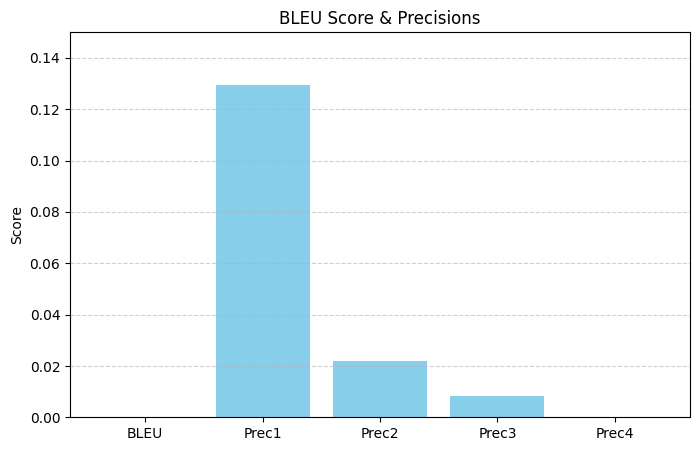

In [55]:
import matplotlib.pyplot as plt

# Plot
plt.figure(figsize=(8, 5))
plt.bar(['BLEU', 'Prec1', 'Prec2', 'Prec3', 'Prec4'], [bleu4] + precisions, color='skyblue')
plt.title('BLEU Score & Precisions')
plt.ylabel('Score')
plt.ylim(0, 0.15)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

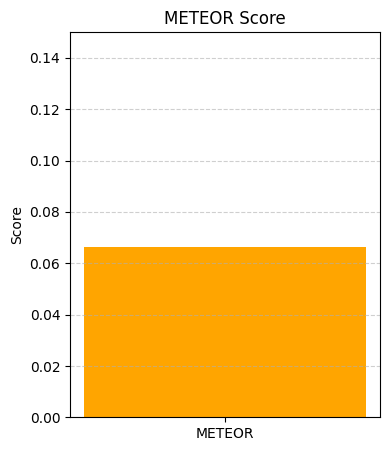

In [58]:


plt.figure(figsize=(4, 5))
plt.bar(['METEOR'], [meteor], color='orange')
plt.title('METEOR Score')
plt.ylabel('Score')
plt.ylim(0, 0.15)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

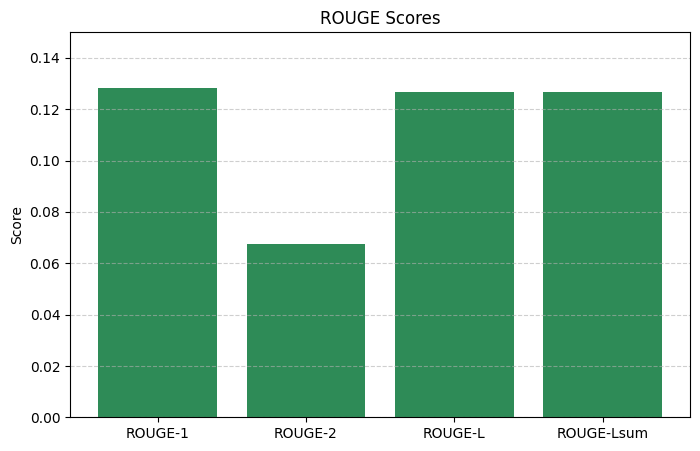

In [59]:

plt.figure(figsize=(8, 5))
plt.bar(rouge_scores.keys(), rouge_scores.values(), color='seagreen')
plt.title('ROUGE Scores')
plt.ylabel('Score')
plt.ylim(0, 0.15)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


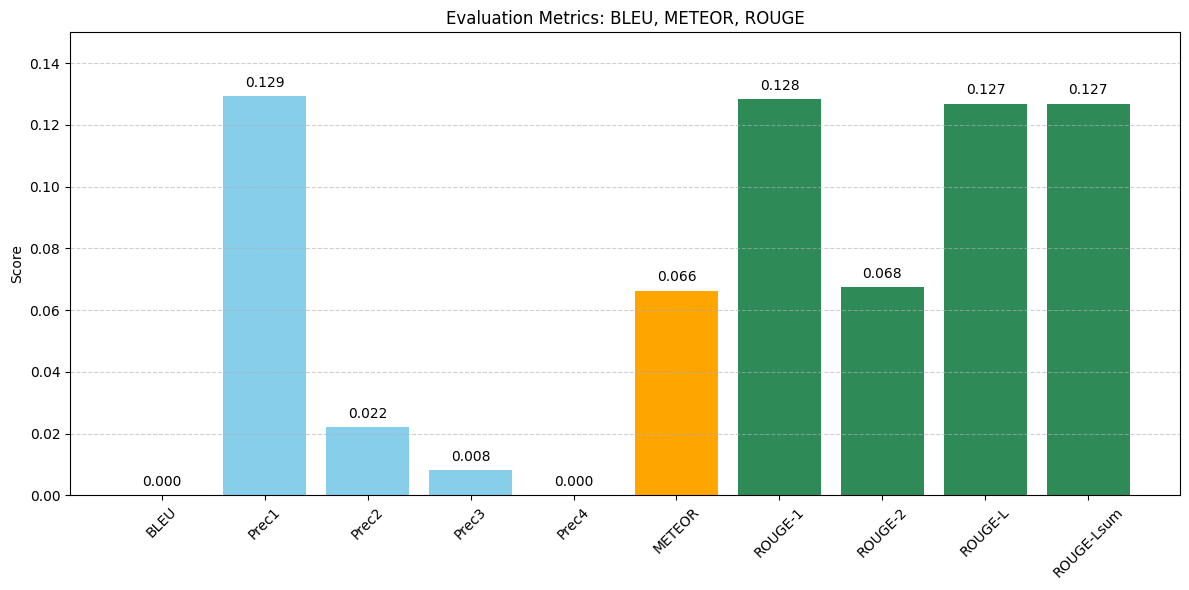

In [60]:
import matplotlib.pyplot as plt

# All scores
labels = [
    'BLEU', 'Prec1', 'Prec2', 'Prec3', 'Prec4',
    'METEOR',
    'ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'ROUGE-Lsum'
]


colors = ['skyblue'] * 5 + ['orange'] + ['seagreen'] * 4

# Plotting
plt.figure(figsize=(12, 6))
bars = plt.bar(labels, scores, color=colors)
plt.title('Evaluation Metrics: BLEU, METEOR, ROUGE')
plt.ylabel('Score')
plt.ylim(0, 0.15)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Adding values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.002, f'{height:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [72]:
generate_report("/content/drive/MyDrive/archive/images/images_normalized/1001_IM-0004-1001.dcm.png", model)



--- Note: The current `generate_report` function is incompatible with `FullModel` (a text generation model). ---

Generated Report: <start> no no acute acute bony bony abnormality abnormality is <end> identified seen <end> the the lungs lungs are are free free of of focal focal airspace airspace disease disease pneumothorax pneumothorax or or pleural pleural effusion. effusion. <end> <end> <end> the the lungs lungs are are free free of of

🧠 Chain of Thought Diagnostic Report
-------------------------------------
➤ Step 1: Extracted lung region features using ResNet18.
➤ Step 2: Applied reasoning layers to interpret these features.
➤ Step 3: Class Probabilities:
    - Benign:    0.00
    - Malignant: 1.00
    - Normal:    0.00
➤ Final Diagnosis: **MALIGNANT CASES**
➤ Explanation:  Based on internal feature representation and classification confidence.

